# Notebook 03: Benchmarking de Modelos, Avaliação e Explicabilidade
Este notebook aplica o conceito de Arena de Modelos. Carregamos a base limpa, submetemos múltiplos algoritmos a um teste cego (Validação Cruzada) e coroamos o vencedor para uso final.

## 1. Carregamento e Divisão (Train/Test Split)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import os
import joblib

# Algoritmos para a Arena
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style="whitegrid")
os.makedirs('../outputs/models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# 1. Carregar base limpa
df = pd.read_csv('../data/processed/df_model.csv')

# Remover caracteres especiais dos nomes das colunas (Exigência do LightGBM)
import re
df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

# 2. Separar X e Y
X = df.drop(columns=['liked'])
y = df['liked']

# 3. Train/Test Split (80/20) estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")


Treino: 46011 amostras
Teste: 11503 amostras


## 2. Arena de Algoritmos (Model Benchmarking)
Testando múltiplos modelos com validação cruzada para garantir que a escolha do campeão é cientificamente fundamentada, e não baseada em palpites.

Iniciando bateria de testes (Cross-Validation K=5)...

[Logistic Regression] Acurácia Média CV: 0.7971 (+/- 0.0059)
[Decision Tree] Acurácia Média CV: 0.7930 (+/- 0.0092)
[Random Forest] Acurácia Média CV: 0.8024 (+/- 0.0048)
[XGBoost] Acurácia Média CV: 0.8161 (+/- 0.0074)
[LightGBM] Acurácia Média CV: 0.8172 (+/- 0.0066)


C:\Users\helio\AppData\Local\Temp\ipykernel_35912\2659534404.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, patch_artist=True, boxprops=dict(facecolor="lightblue"))


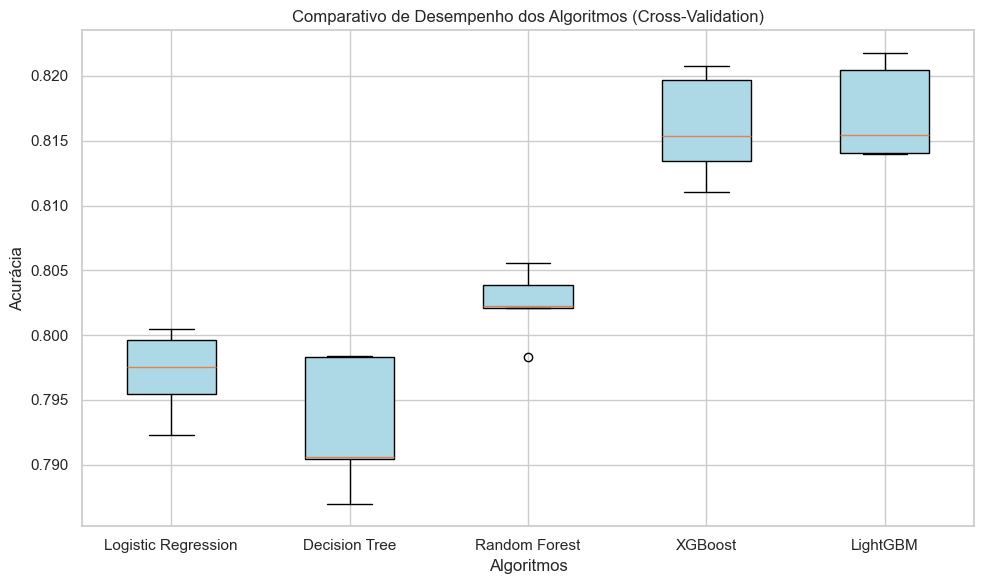


🏆 MODELO CAMPEÃO: LightGBM com acurácia média de 0.8172!


In [ ]:
# Definir dicionário de modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = []
names = []

print("Iniciando bateria de testes (Cross-Validation K=5)...\n")

for name, model in models.items():
    # cv=5 testa o modelo em 5 fatias diferentes do dado de treino
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    results.append(cv_scores)
    names.append(name)
    print(f"[{name}] Acurácia Média CV: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Plotar Comparativo de Desempenho
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title('Comparativo de Desempenho dos Algoritmos (Cross-Validation)')
plt.ylabel('Acurácia')
plt.xlabel('Algoritmos')
plt.tight_layout()
plt.savefig('../outputs/figures/model_benchmarking.png', dpi=300)
plt.show()

# Encontrar o vencedor matematicamente
mean_scores = [scores.mean() for scores in results]
best_model_idx = np.argmax(mean_scores)
best_model_name = names[best_model_idx]
best_model = models[best_model_name]

print(f"\n🏆 MODELO CAMPEÃO: {best_model_name} com acurácia média de {mean_scores[best_model_idx]:.4f}!")


## 3. Treinamento Final e Avaliação do Campeão
Agora que provamos quem é o melhor algoritmo, vamos treiná-lo em todo o dataset de treino e testar na base isolada de teste.

Treinando o LightGBM...
[LightGBM] [Info] Number of positive: 23006, number of negative: 23005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 743
[LightGBM] [Info] Number of data points in the train set: 46011, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500011 -> initscore=0.000043
[LightGBM] [Info] Start training from score 0.000043

--- Classification Report (LightGBM) ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      5752
           1       0.79      0.86      0.82      5751

    accuracy                           0.82     11503
   macro avg       0.82      0.82      0.82     11503
weighted avg       0.82      0.82      0.82     11503

AUC-ROC Score: 0.8957


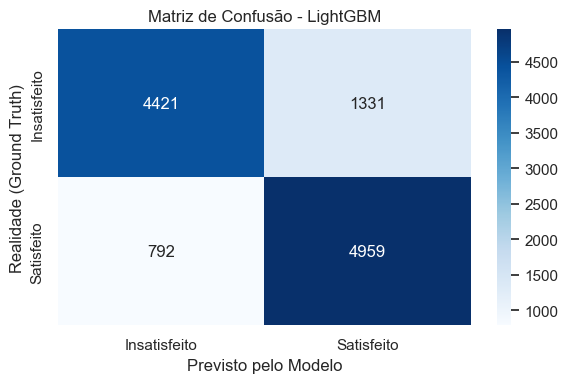

In [ ]:
# Treinamento
print(f"Treinando o {best_model_name}...")
best_model.fit(X_train, y_train)

# Previsões
y_pred = best_model.predict(X_test)
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
else:
    roc_auc = "N/A (O modelo não emite probabilidades)"

print(f"\n--- Classification Report ({best_model_name}) ---")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc if isinstance(roc_auc, str) else f'{roc_auc:.4f}'}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Insatisfeito', 'Satisfeito'], 
            yticklabels=['Insatisfeito', 'Satisfeito'])
plt.title(f'Matriz de Confusão - {best_model_name}')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Realidade (Ground Truth)')
plt.tight_layout()
plt.savefig('../outputs/figures/matriz_confusao.png', dpi=300)
plt.show()


## 4. Explicabilidade e Exportação
O que fez o modelo tomar essas decisões? Quais serviços mais importam para a Inteligência Artificial?

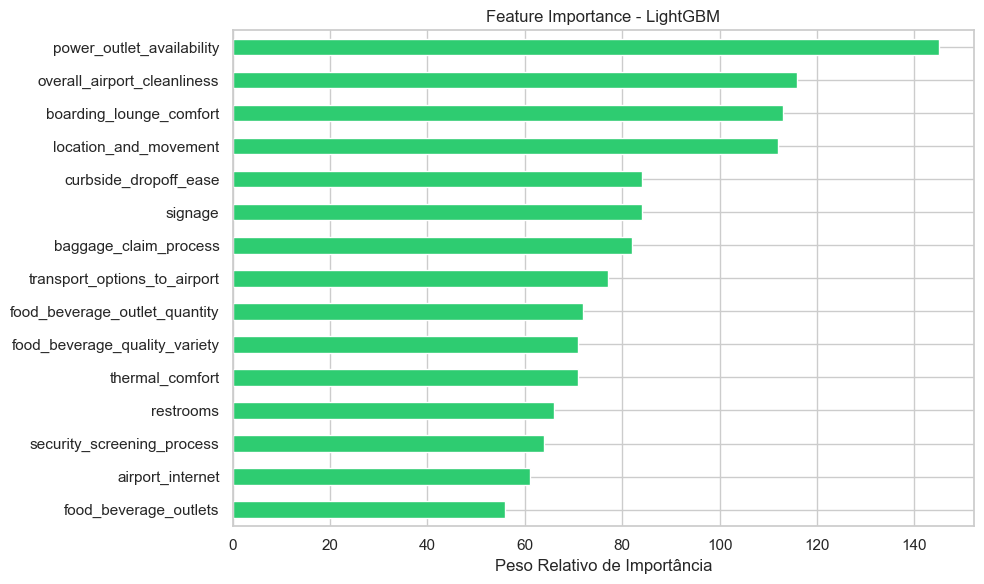

Modelo campeão exportado e salvo com sucesso em: ../outputs/models/melhor_modelo_lightgbm.pkl


In [ ]:
# Tentativa de extrair Feature Importances
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_features = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    top_features.plot(kind='barh', color='#2ecc71')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.xlabel('Peso Relativo de Importância')
    plt.tight_layout()
    plt.savefig('../outputs/figures/feature_importance.png', dpi=300)
    plt.show()
else:
    print(f"Atenção: O modelo {best_model_name} não fornece o atributo 'feature_importances_' nativamente.")

# Exportar o Modelo
# Substituindo espaços por underline para não quebrar o nome do arquivo
model_filename = best_model_name.lower().replace(' ', '_')
model_path = f'../outputs/models/melhor_modelo_{model_filename}.pkl'
joblib.dump(best_model, model_path)
print(f"Modelo campeão exportado e salvo com sucesso em: {model_path}")
